Test MAE: 16.507905960083008
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


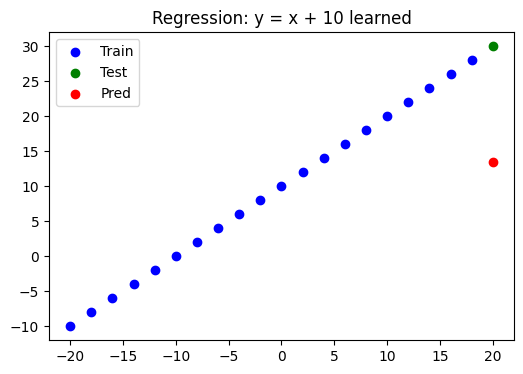

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
# Synthetic linear data
X = np.arange(-20, 21, 2, dtype=np.float32) # [-20, -18, ..., 20]
y = X + 10
# Train/test split (simple)
# Divide it into a Training set (for learning) and a Test set (to check if the model truly understands the rules or is just memorizing them).
X_train, y_train = X[:20], y[:20]
X_test, y_test = X[20:], y[20:]
# 1) CREATE
model = tf.keras.Sequential([
tf.keras.layers.Input(shape=(1,)),
tf.keras.layers.Dense(1) # linear output for regression
])
# 2) COMPILE
model.compile(
loss="mae",
optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
metrics=["mae"]
)
# 3) FIT
# Let the model view the data set Train repeated 200 times (epochs=200).
history = model.fit(X_train, y_train, epochs=200, verbose=0)
# Evaluate
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print("Test MAE:", mae)
# Predict and visualize
y_pred = model.predict(X_test).squeeze()
plt.figure(figsize=(6,4))
plt.scatter(X_train, y_train, c='b', label='Train')
plt.scatter(X_test, y_test, c='g', label='Test')
plt.scatter(X_test, y_pred, c='r', label='Pred')
plt.legend(); plt.title("Regression: y = x + 10 learned")
plt.show()